# Signal-to-Noise Ratio (SNR) Analysis of AES SW running on X-HEEP

This notebook computes the **Signal-to-Noise Ratio (SNR)** for the selected AES leakage model using the traces captured earlier.

The SNR curve highlights the time samples where the leakage model is strongest, helping understand:
- where information about the S-box output leaks,
- how well the traces match the theoretical leakage assumptions,
- and which parts of the trace are most exploitable for attacks.

⚠️ **Important:**  
This notebook requires that the **Power Trace Acquisition** notebook (`xheep_capture_AES.ipynb`) has been run first, since it loads the traces from the generated `.cwp` file.


In [1]:
import sys
import os
import time
from pathlib import Path

## Project paths
This block robustly detects the project root (`DOJO_ROOT`) starting from either the script location (`__file__`) or the current working directory (for notebooks). From there it defines all relevant subdirectories (AES sources, SCA scripts, X-HEEP, traces, plots, cache), ensures output folders exist, and adds the local source paths to `sys.path` .

In [2]:
from pathlib import Path

def find_project_root(start: Path, markers=("fusesoc.conf", ".dojo_root")) -> Path:
    current = start
    while current != current.parent:
        if any((current / m).exists() for m in markers):
            return current
        current = current.parent

    raise RuntimeError(
        f"Could not find project root (looked for markers: {markers}). "
        "Please ensure you are inside the Side-Channel-Dojo repository."
    )

# In a script, __file__ exists; in a notebook, it does not.
try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    # Notebook / interactive: use the current working directory instead
    SCRIPT_DIR = Path.cwd()

DOJO_ROOT = find_project_root(SCRIPT_DIR)

AES_PY_DIR   = DOJO_ROOT / "sw" / "ciphers" / "AES_python"
SCA_DIR      = DOJO_ROOT / "sw" / "sca_scripts"
HW_DIR       = DOJO_ROOT / "hw"

# Specific sub-dirs used by this script
XHEEP_DIR           = DOJO_ROOT / "sw" / "x-heep"
TRACESET_DIR        = DOJO_ROOT / "sw" / "traceset" / "AES" / "sw"
BASE_PLOT_DIR       = DOJO_ROOT / "sw" / "sca_scripts" / "AES" / "sw" / "plot" 
BASE_CACHE_DIR      = DOJO_ROOT / "sw" / "sca_scripts" / "AES" / "sw" / "cache" 

# Ensure traceset and plot directories exist
TRACESET_DIR.mkdir(parents=True, exist_ok=True)

# Make local modules importable without fragile ../ relative paths
sys.path.insert(0, str(AES_PY_DIR))
sys.path.insert(0, str(SCA_DIR))
sys.path.insert(0, str(XHEEP_DIR))

## Imports

In [3]:
import chipwhisperer as cw
import chipwhisperer.analyzer as cwa
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import json
from analyzer.attack.aes.SBox_leakage_models import AES128SboxResistantLeakageModels

## Initialization

In [4]:
# Available S-box implementations
AVAILABLE_SBOXES = [
    "sbox_rijandael  (default AES S-Box, aes_sbox)",
    "sbox_freyre_1",
    "sbox_freyre_2",
    "sbox_freyre_3",
    "sbox_hussain_6",
    "sbox_ozkaynak_1",
    "sbox_azam_1",
    "sbox_azam_2",
    "sbox_azam_3",
]

# Default S-box to test
tested_sbox = "sbox_rijandael"
sbox_id = tested_sbox.replace("sbox_", "")

# Whether we are attacking a masked firmware or the plain S-box firmware
masked_flag = False

# ---------------------------------------------------------------------------
# Flow flags
# ---------------------------------------------------------------------------

# Output control
save_plots              = True   # Save plots to disk
save_results            = True   # Save analysis results to disk
load_snr_from_cache     = False  # set True to plot previous SNR computation
# ---------------------------------------------------------------------------
# Bitstream, defines, firmware, project, directories
# ---------------------------------------------------------------------------

# Firmware and project (.cwp) paths:
# - Firmware is under DOJO_ROOT/sw/x-heep
# - Project is under DOJO_ROOT/sw/traceset/AES/sw
if masked_flag:
    project_file_path = TRACESET_DIR / f"CW305_xheep_AES_{sbox_id}_masked.cwp"
else:
    project_file_path = TRACESET_DIR / f"CW305_xheep_AES_{sbox_id}.cwp"

project_file = str(project_file_path)

CACHE_DIR = BASE_CACHE_DIR / tested_sbox
PLOT_DIR = BASE_PLOT_DIR / tested_sbox

# Ensure traceset and plot directories exist
TRACESET_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
SNR_CACHE_FILE = CACHE_DIR / f"SNR_{tested_sbox}.json"


# ---------------------------------------------------------------------------
# Configuration printout
# ---------------------------------------------------------------------------

def _yn(flag: bool) -> str:
    """Return 'yes' or 'no' for a boolean flag."""
    return "yes" if flag else "no"



print("\n================= CONFIGURATION =================")
print(f"DOJO_ROOT           : {DOJO_ROOT}")
print()
print("Target")
print(f"  Tested S-box              : {tested_sbox}")
print(f"  Masked firmware           : {_yn(masked_flag)}")
print()
print("Paths")
print(f"  CW project (.cwp)         : {project_file}")
print(f"  Traceset dir              : {TRACESET_DIR}")
print(f"  Plot dir                  : {PLOT_DIR}")
print(f"  Cache dir                 : {CACHE_DIR}")
print(f"  SNR cache file            : {SNR_CACHE_FILE}")
print()
print("Offline phase / SNR analysis")
print(f"  Save plots                : {_yn(save_plots)}")
print(f"  Save results              : {_yn(save_results)}")
print(f"  Load SNR from cache       : {_yn(load_snr_from_cache)}")
print("=================================================\n")



================= CONFIGURATION =================
DOJO_ROOT           : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo

Target
  Tested S-box              : sbox_rijandael
  Masked firmware           : no

Paths
  CW project (.cwp)         : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/AES/sw/CW305_xheep_AES_rijandael.cwp
  Traceset dir              : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/AES/sw
  Plot dir                  : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/AES/sw/plot/sbox_rijandael
  Cache dir                 : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/AES/sw/cache/sbox_rijandael
  SNR cache file            : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/AES/sw/cache/sbox_rijandael/SNR_sbox_rijandael.json

Offline phase / SNR analysis
  Save plots                : yes
  Save results              : yes
  Load SNR from cache       : no



## Opening the cwa Project

In [5]:
try:
    # Open the project for offline analysis
    project = cw.open_project(project_file)
    print(f"[OFFLINE] Loaded project file: {project_file}")
except Exception as e:
    print(f"[ERROR] Failed to open project file '{project_file}': {e}")

    # If the file does not exist, give a clear hint about the capture notebook
    if not Path(project_file).exists():
        print(
            "[HINT] The ChipWhisperer project file does not exist.\n"
            "       Make sure you have run the power-trace capture notebook "
            "'xheep_capture_AES.ipynb' (or the equivalent capture script) first."
        )

    # Re-raise so the notebook stops instead of continuing with an invalid state
    raise

[OFFLINE] Loaded project file: /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/AES/sw/CW305_xheep_AES_rijandael.cwp


## Calculating the SNR

In [6]:
def save_snr_results(snr_array, filename, meta=None):
    """
    Save SNR curve and optional metadata to a JSON cache file.

    Args:
        snr_array: numpy array of float64 (e.g., output of calculate_snr).
        filename: path to the JSON file.
        meta: optional dict with extra info (e.g., tested_sbox, N, etc.).
    """
    if meta is None:
        meta = {}

    data = {
        "snr": snr_array.tolist(),   # JSON-serializable
        "dtype": "float64",          # for clarity
        "meta": meta,
    }
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, "w") as f:
        json.dump(data, f)


def load_snr_results(filename):
    """
    Load SNR curve and metadata from a JSON cache file.

    Returns:
        snr_array: numpy array of dtype float64
        meta: dict with any stored metadata
    """
    with open(filename, "r") as f:
        data = json.load(f)

    snr_array = np.array(data["snr"], dtype=np.float64)
    meta = data.get("meta", {})
    return snr_array, meta

## SNR computation + optional caching

In [7]:
print("Generating SNR plot...")

snr_fr = None
snr_meta = {}

# Try to load SNR from cache if requested
if load_snr_from_cache:
    try:
        snr_fr, snr_meta = load_snr_results(SNR_CACHE_FILE)
        print(f"[OFFLINE] Loaded cached SNR from: {SNR_CACHE_FILE}")
    except FileNotFoundError:
        print(f"[WARN] SNR cache file not found at {SNR_CACHE_FILE}, recomputing SNR.")
        load_snr_from_cache = False
    except Exception as e:
        print(f"[ERROR] Failed to load SNR cache from {SNR_CACHE_FILE}: {e}")
        load_snr_from_cache = False

# If not loaded from cache, compute SNR
if not load_snr_from_cache:
    leak_model = AES128SboxResistantLeakageModels().FirstRound_ModifiedSbox_Output(
        tested_sbox
    )
    snr_fr = cwa.calculate_snr(project.traces, leak_model=leak_model, db=False)

    if save_results:
        snr_meta = {
            "tested_sbox": tested_sbox,
            "masked": masked_flag,
            "num_traces": len(project.traces),
        }
        save_snr_results(snr_fr, SNR_CACHE_FILE, meta=snr_meta)
        print(f"[OFFLINE] SNR results cached to: {SNR_CACHE_FILE}")

Generating SNR plot...
[OFFLINE] SNR results cached to: /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/AES/sw/cache/sbox_rijandael/SNR_sbox_rijandael.json


## Plot SNR

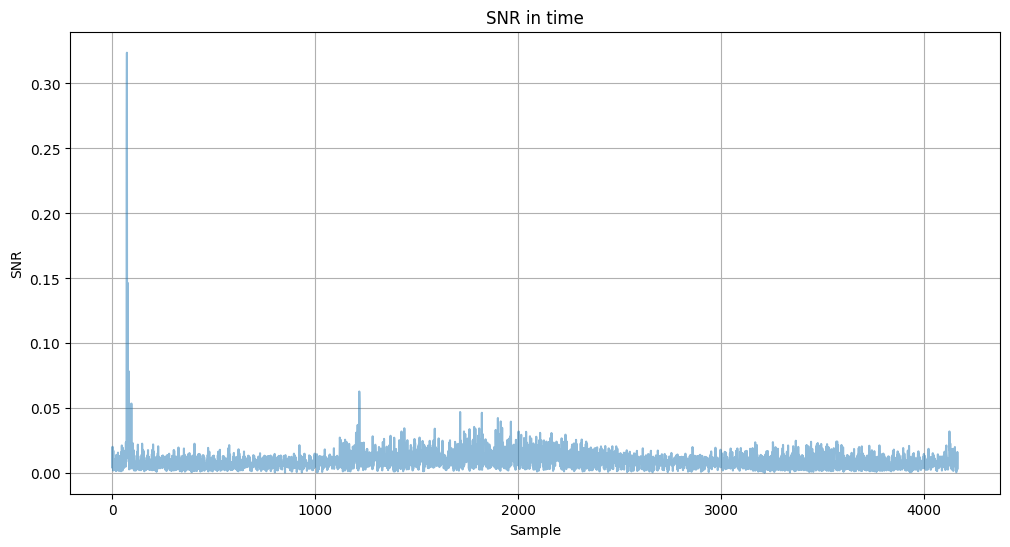

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(snr_fr)), snr_fr, alpha=0.5)
plt.xlabel("Sample")
plt.ylabel("SNR")
plt.title("SNR in time")
plt.grid(True)

out_file = (
    PLOT_DIR
    / (
        f"AES_masked_SNR_{tested_sbox}.png"
        if masked_flag
        else f"AES_SNR_{tested_sbox}_masked.png"
    )
)
if save_plots:
    plt.savefig(out_file)
plt.show()  
plt.close()